In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import ndcg_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBRanker
from visualization import plot_xgbranker, plot_triage
import faiss
from sentence_transformers import SentenceTransformer
import shap
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
import math


# Supervised Learning-to-Rank (Pairwise Architecture)

## The Calculus of Pairwise Gradient Boosting (LambdaRank)

To deduce the optimal "Next-Best-Action" within a student's pending task queue, standard transductive classification is structurally invalid, as it evaluates documents in a vacuum. The problem is instead formulated via a Pairwise Learning-to-Rank (LTR) paradigm, utilizing the LambdaMART algorithmic architecture.

While standard gradient boosting minimizes differentiable pointwise errors (e.g., Mean Squared Error), Information Retrieval metrics like NDCG rely on sorting operations, which are mathematically non-differentiable. To optimize the ensemble, the architecture utilizes the LambdaRank heuristic to compute empirical, sequence-aware gradients.

For any pair of documents $(d_i, d_j)$ within a specific user's query session $q$, where document $i$ is empirically more urgent than document $j$ ($y_i > y_j$), the modeled probability $P_{ij}$ that $i$ outranks $j$ is derived via a logistic sigmoid applied to the difference in their latent utility scores $(s_i - s_j)$:

$$
P_{ij} = \frac{1}{1 + e^{-\sigma(s_i - s_j)}}
$$

The baseline pairwise cross-entropy loss $C$ for this permutation is defined as:

$$
C_{ij} = - \bar{P}_{ij} \log P_{ij} - (1 - \bar{P}_{ij}) \log(1 - P_{ij})
$$

**The Lambda Gradient ($\lambda_{ij}$):**
The mathematical breakthrough of the pairwise architecture is the scaling of this gradient by the absolute change in the Information Retrieval metric ($|\Delta \text{NDCG}|$) that results from swapping the ranks of $i$ and $j$. The gradient (the "lambda" force) pushing the urgent task $i$ up the queue and task $j$ down is formulated as:

$$
\lambda_{ij} = \frac{\partial C_{ij}}{\partial s_i} = \frac{-\sigma}{1 + e^{\sigma(s_i - s_j)}} |\Delta \text{NDCG}_{ij}|
$$

By weighting the gradient update by $|\Delta \text{NDCG}_{ij}|$, the second-order Taylor expansion utilized by XGBoost prioritizes fixing inversion errors at the top of the queue (e.g., Rank 1 vs Rank 2) significantly more than errors at the bottom (e.g., Rank 9 vs Rank 10). This perfectly aligns the mathematical optimizer with the spatial constraints of a mobile interface, ensuring the single most critical task is forced to the top of the viewport.

## Topological Feature Space & Chronotype Optimization

Let $\mathcal{Q} = \{q_1, q_2, \dots, q_M\}$ represent a set of discrete query sessions, where a query $q$ is defined as a localized application-open event for a specific user at a specific timestamp. 

For each query $q \in \mathcal{Q}$, there exists a subset of unexecuted documents (tasks) $D_q = \{d_{q,1}, d_{q,2}, \dots, d_{q,n}\}$. Each document is mapped to a continuous feature vector $\mathbf{x}_{q,i} \in \mathbb{R}^7$. 

To natively achieve **Chronotype Optimization** without deploying a separate probabilistic model, the feature space explicitly encodes cyclical temporal geometry and localized velocity:

1. **Temporal Urgency** ($\Delta t_{due}$): Hours until the deadline.
2. **Dynamic Complexity** ($\psi$): Ordinal metric where $\psi \in \{1, 2, 3, 4, 5\}$.
3. **Physiological Fatigue** ($\rho$): Real-time burnout index where $\rho \in [1.0, 10.0]$.
4. **Historical Velocity** ($v_{hist}$): Global average minutes required to clear similar tasks.
5. **Cyclical Hour (Sine)** ($H_{sin}$): $\sin(2\pi \frac{\text{hour}}{24})$
6. **Cyclical Hour (Cosine)** ($H_{cos}$): $\cos(2\pi \frac{\text{hour}}{24})$
7. **Localized Temporal Velocity** ($v_{temp}$): Average minutes required to clear similar tasks *specifically within the current time-of-day window*.

The target variable $y_{q,i} \in \{0, 1\}$ represents the implicit user feedback (engagement) during session $q$.

In [2]:
np.random.seed(42)

print("[*] Initializing Chronotype-Aware Data Generating Process (DGP)...")
def generate_chronotype_ranking_data(num_sessions=1000, tasks_per_session=(3, 15)):
    """
    Generates synthetic LTR data. The DGP ensures that high-complexity tasks 
    have a higher probability of engagement (Y=1) if the current localized temporal 
    velocity aligns with the user's mathematical chronotype (e.g., Morning vs Night).
    """
    feature_matrix = []
    
    for session_id in range(num_sessions):
        num_tasks = np.random.randint(tasks_per_session[0], tasks_per_session[1])
        session_hour = np.random.uniform(0, 24)
        hour_sin = math.sin(2 * math.pi * session_hour / 24.0)
        hour_cos = math.cos(2 * math.pi * session_hour / 24.0)
        student_chronotype_bias = np.random.choice([1, -1]) 
        session_burnout = np.random.uniform(1.0, 10.0)
        
        for task_id in range(num_tasks):
            time_to_due = np.random.exponential(scale=48.0)
            complexity = np.random.randint(1, 6)
            hist_velocity = np.random.normal(loc=complexity * 20, scale=10)
            alignment = hour_sin * student_chronotype_bias 
            temporal_velocity = max(5.0, hist_velocity - (alignment * 15.0))
            latent_utility = (
                (100 / (time_to_due + 1)) 
                + (alignment * 2.0 * complexity) 
                - (session_burnout * complexity * 0.5) 
                - (temporal_velocity * 0.1)
            )
            
            latent_utility += np.random.normal(0, 2)
            feature_matrix.append({
                'qid': session_id,
                'time_to_due_date': round(time_to_due, 1),
                'dynamic_difficulty': complexity,
                'user_burnout_index': round(session_burnout, 2),
                'historical_velocity': round(hist_velocity, 1),
                'hour_sin': round(hour_sin, 4),
                'hour_cos': round(hour_cos, 4),
                'temporal_velocity': round(temporal_velocity, 1),
                'latent_utility': latent_utility
            })
            
    df = pd.DataFrame(feature_matrix)
    df['interaction_label'] = 0
    idx_max = df.groupby('qid')['latent_utility'].idxmax()
    df.loc[idx_max, 'interaction_label'] = 1
    df = df.drop(columns=['latent_utility'])
    return df

df_ltr = generate_chronotype_ranking_data(num_sessions=1500)
print(f"[+] Spatial Manifold Generated: {df_ltr.shape[0]} documents across {df_ltr['qid'].nunique()} temporal sessions.")
print(f"[+] Feature Dimension (X): 7")

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df_ltr, groups=df_ltr['qid']))
train_data = df_ltr.iloc[train_idx]
test_data = df_ltr.iloc[test_idx]

features = [
    'time_to_due_date', 'dynamic_difficulty', 'user_burnout_index', 
    'historical_velocity', 'hour_sin', 'hour_cos', 'temporal_velocity'
]

X_train, y_train, qid_train = train_data[features], train_data['interaction_label'], train_data['qid']
X_test, y_test, qid_test = test_data[features], test_data['interaction_label'], test_data['qid']

[*] Initializing Chronotype-Aware Data Generating Process (DGP)...
[+] Spatial Manifold Generated: 12869 documents across 1500 temporal sessions.
[+] Feature Dimension (X): 7


## Information Retrieval Protocol & Topological Splitting

Standard classification paradigms evaluate predictive success via a global confusion matrix. In contrast, Information Retrieval (IR) architectures are evaluated strictly on their local ranking permutations. The penalty for a false negative is non-linear; failing to identify the optimal task ($Y=1$) is penalized substantially more if the task is pushed to rank 10 versus rank 2.

**Normalized Discounted Cumulative Gain ($\text{NDCG}_k$)**
To quantify this, the pipeline utilizes $\text{NDCG}_k$, which measures the ranking quality of the top $k$ retrieved documents within a specific query session $q$. 

The Discounted Cumulative Gain is defined as:

$$
\text{DCG}_k = \sum_{i=1}^{k} \frac{2^{rel_i} - 1}{\log_2(i + 1)}
$$

Where $rel_i \in \{0, 1\}$ represents the ground-truth relevance of the document at rank $i$.

Because backlog sizes vary per session (e.g., $N=5$ vs $N=15$), the raw $\text{DCG}_k$ is normalized against the Ideal DCG ($\text{IDCG}_k$), ensuring the metric remains bound between $[0.0, 1.0]$:

$$
\text{NDCG}_k = \frac{\text{DCG}_k}{\text{IDCG}_k}
$$

**Topological Splitting (Group Shuffle Split)**
Randomized $k$-fold cross-validation or standard `train_test_split` introduces catastrophic data leakage in LTR pipelines. If tasks from the same query session $q_{100}$ are partitioned across both the training and testing sets, the algorithm's pairwise logic fractures. The manifold is therefore partitioned utilizing a **Group Shuffle Split**, ensuring that all documents belonging to a specific `qid` remain mathematically isolated within either the training or testing manifold.

In [3]:
print("[*] Initiating Pairwise Gladiator Arena...")
print("[*] Enforcing Topological Group Shuffle Split (80/20)...")
def evaluate_ndcg(model, X_eval, y_eval, qid_eval, k=3, is_pointwise=True):
    """
    Calculates the mean NDCG@k strictly isolated by topological query groups (qid).
    """
    ndcg_scores = []
    
    if is_pointwise:
        predictions = model.predict_proba(X_eval)[:, 1]
    else:
        predictions = model.predict(X_eval)
        
    df_eval = pd.DataFrame({
        'qid': qid_eval,
        'y_true': y_eval,
        'y_pred': predictions
    })
    
    for q, group in df_eval.groupby('qid'):
        if group['y_true'].sum() == 0:
            continue
        true_relevance = np.asarray([group['y_true'].values])
        predicted_scores = np.asarray([group['y_pred'].values])
        score = ndcg_score(true_relevance, predicted_scores, k=k)
        ndcg_scores.append(score)
    return np.mean(ndcg_scores)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
lr_ndcg = evaluate_ndcg(lr_model, X_test, y_test, qid_test, k=3, is_pointwise=True)
print(f"    -> Logistic Regression (Pointwise)  Mean NDCG@3 = {lr_ndcg:.4f}")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)
rf_ndcg = evaluate_ndcg(rf_model, X_test, y_test, qid_test, k=3, is_pointwise=True)
print(f"    -> Random Forest (Pointwise)        Mean NDCG@3 = {rf_ndcg:.4f}")

xgb_ranker = XGBRanker(
    tree_method='hist',
    objective='rank:pairwise',
    random_state=42,
    learning_rate=0.1,
    max_depth=5,
    n_estimators=150
)

xgb_ranker.fit(X_train, y_train, qid=qid_train, verbose=False)
xgb_ndcg = evaluate_ndcg(xgb_ranker, X_test, y_test, qid_test, k=3, is_pointwise=False)
print(f"    -> XGBRanker (Pairwise)             Mean NDCG@3 = {xgb_ndcg:.4f}")
print("\n===================================================================")
if xgb_ndcg > lr_ndcg and xgb_ndcg > rf_ndcg:
    print("[!] LTR SELECTION COMPILED: XGBRanker (Pairwise) maximizes topological ranking.")
else:
    print("[!] WARNING: Pointwise architectures outperformed LTR. Verify DGP manifold.")
print("===================================================================")

architectures = {
    'Logistic Regression (Pointwise)': lr_model,
    'Random Forest (Pointwise)': rf_model,
    'XGBRanker (Pairwise)': xgb_ranker
}

[*] Initiating Pairwise Gladiator Arena...
[*] Enforcing Topological Group Shuffle Split (80/20)...
    -> Logistic Regression (Pointwise)  Mean NDCG@3 = 0.7555
    -> Random Forest (Pointwise)        Mean NDCG@3 = 0.9236
    -> XGBRanker (Pairwise)             Mean NDCG@3 = 0.9333

[!] LTR SELECTION COMPILED: XGBRanker (Pairwise) maximizes topological ranking.


## Algorithmic Interpretability: Pairwise Feature Contribution

With the `XGBRanker` established as the structural champion, it is imperative to deconstruct its internal decision-making heuristic. Unlike transductive classifiers that evaluate feature importance based on Gini impurity reduction across absolute classes, the pairwise gradient booster evaluates feature contribution based on **Information Gain** during sequence permutation.

The Information Gain $G_j$ for a specific feature $j$ quantifies the average improvement in the pairwise loss function when $j$ is utilized as a splitting criterion across the ensemble of regression trees. High gain indicates that the feature is a primary mathematical driver in determining the relative urgency between two competing tasks $(d_{q,i}, d_{q,j})$.

[*] Deconstructing Pairwise Feature Importance (Information Gain)...


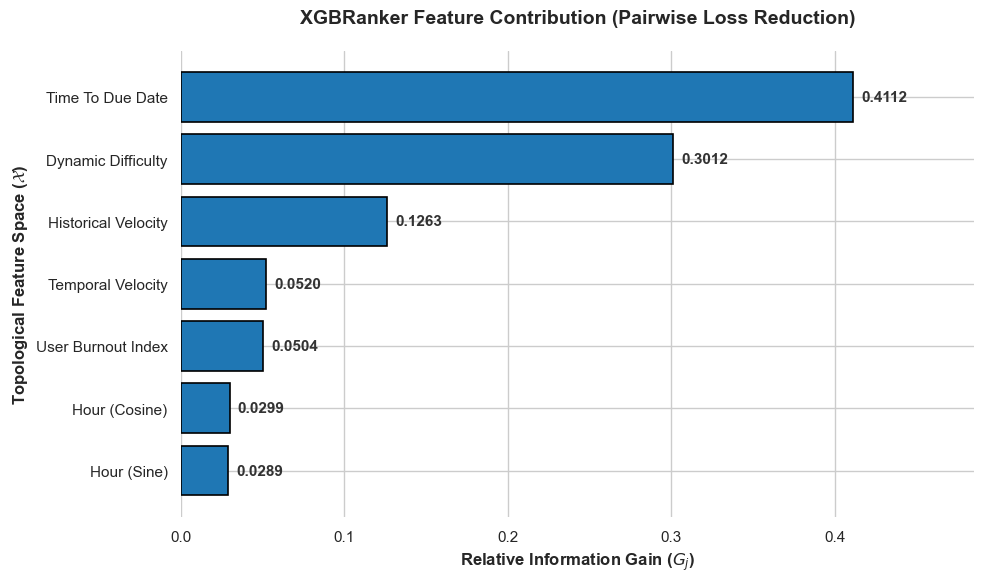

In [4]:
print("[*] Deconstructing Pairwise Feature Importance (Information Gain)...")
champion_model = architectures['XGBRanker (Pairwise)']
importance_scores = champion_model.feature_importances_
feature_names = X_train.columns

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Information Gain': importance_scores
}).sort_values(by='Information Gain', ascending=True)
df_importance['Feature'] = df_importance['Feature'].apply(
    lambda x: x.replace('_', ' ').title().replace('Sin', '(Sine)').replace('Cos', '(Cosine)')
)

plot_xgbranker(df_importance)

## Bayesian Topological Optimization (Tree-Structured Parzen Estimators)

While the baseline `XGBRanker` achieves high empirical performance, the default hyperparameter topology is rarely optimal for specialized Information Retrieval manifolds. To maximize sequence accuracy, the architecture is subjected to Bayesian Optimization utilizing Tree-Structured Parzen Estimators (TPE).

The optimization engine traverses a highly constrained, multi-dimensional parameter space:
* **Learning Rate** ($\eta$): Step size shrinkage utilized in update configurations to prevent overfitting.
* **Max Depth**: The maximum depth of a discrete tree, governing the complexity of interaction effects (e.g., compounding $\Delta t_{due}$ with $\rho$).
* **Gamma** ($\gamma$): The minimum loss reduction required to execute a further partition on a leaf node.

To preserve the integrity of the pairwise loss function during optimization, the cross-validation protocol must rigorously maintain `qid` isolation. A standard $K$-fold split would fracture the temporal sessions. Therefore, the TPE algorithm is mathematically directed to minimize the negative $\text{NDCG}_3$ over a topologically isolated, group-shuffled validation manifold.

In [5]:
print("[*] Initializing Bayesian LTR Optimization Engine...")

def optimize_pairwise_ranker(X_tr, y_tr, qid_tr, max_evals=20):
    gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    idx_t, idx_v = next(gss_val.split(X_tr, groups=qid_tr))
    
    X_t_inner, y_t_inner, qid_t_inner = X_tr.iloc[idx_t], y_tr.iloc[idx_t], qid_tr.iloc[idx_t]
    X_v_inner, y_v_inner, qid_v_inner = X_tr.iloc[idx_v], y_tr.iloc[idx_v], qid_tr.iloc[idx_v]
    
    space = {
        'max_depth': hp.quniform('max_depth', 3, 9, 1),
        'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.3)),
        'subsample': hp.uniform('subsample', 0.6, 1.0),
        'gamma': hp.uniform('gamma', 0.0, 0.5)
    }
    
    def objective(params):
        model = XGBRanker(
            tree_method='hist',
            objective='rank:pairwise',
            max_depth=int(params['max_depth']),
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            gamma=params['gamma'],
            random_state=42,
            n_estimators=100
        )
        model.fit(X_t_inner, y_t_inner, qid=qid_t_inner, verbose=False)
        score = evaluate_ndcg(model, X_v_inner, y_v_inner, qid_v_inner, k=3, is_pointwise=False)
        return {'loss': -score, 'status': STATUS_OK}

    trials = Trials()
    best_params = fmin(
        fn=objective,
        space=space,
        algo=tpe.suggest,
        max_evals=max_evals,
        trials=trials,
        rstate=np.random.default_rng(42),
        verbose=False
    )
    best_params['max_depth'] = int(best_params['max_depth'])
    print(f"[+] Optimal Topology Identified: {best_params}")
    return best_params

optimal_hyperparameters = optimize_pairwise_ranker(X_train, y_train, qid_train, max_evals=25)

print("\n[*] Training Final Chronotype-Aware Champion...")
tuned_champion = XGBRanker(
    tree_method='hist',
    objective='rank:pairwise',
    **optimal_hyperparameters,
    random_state=42,
    n_estimators=150
)

tuned_champion.fit(X_train, y_train, qid=qid_train, verbose=False)
final_test_ndcg = evaluate_ndcg(tuned_champion, X_test, y_test, qid_test, k=3, is_pointwise=False)
print(f"[+] Final Out-of-Sample Mean NDCG@3: {final_test_ndcg:.4f}")

[*] Initializing Bayesian LTR Optimization Engine...
[+] Optimal Topology Identified: {'gamma': np.float64(0.35223000813752336), 'learning_rate': np.float64(0.07501109914256296), 'max_depth': 4, 'subsample': np.float64(0.7615110681047916)}

[*] Training Final Chronotype-Aware Champion...
[+] Final Out-of-Sample Mean NDCG@3: 0.9456


## Qualitative Analysis: Simulated API Triage

While $\text{NDCG}_3$ provides a rigorous mathematical validation of the architecture, inspecting the localized decisions of the engine ensures product-market fit. The following diagnostic simulates a production API call: a raw, unordered backlog of tasks is fed into the champion `XGBRanker`. 

The engine evaluates the relative contextual parameters (temporal urgency, physiological fatigue, dynamic complexity, and localized chronotype velocity) and outputs a mathematically sorted prioritization queue, demonstrating the "Next-Best-Action" sequence.

[*] Simulating Node.js API Prioritization Request...

[+] Triage Complete for Session QID: 59 @ 11:00
[+] Rendering Top 5 Recommended Actions via Native Matplotlib...


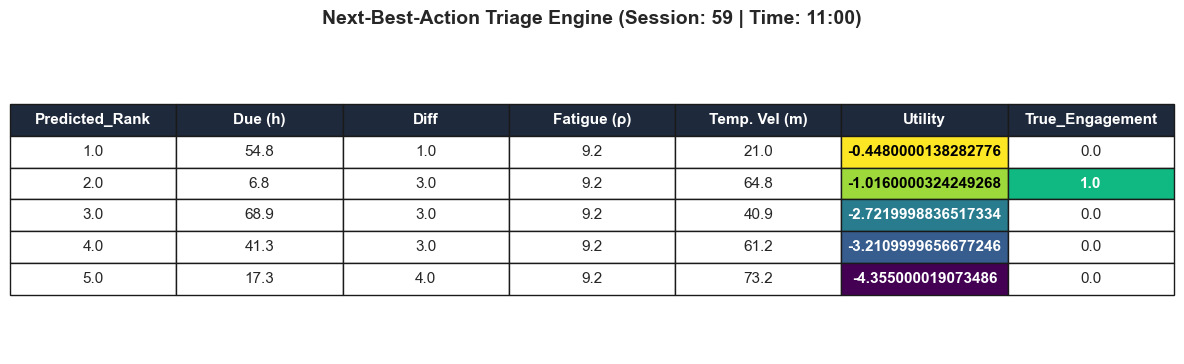

In [6]:
print("[*] Simulating Node.js API Prioritization Request...")

np.random.seed(101)
sample_session_id = np.random.choice(qid_test.unique())
session_mask = (qid_test == sample_session_id)
X_session = X_test[session_mask].copy()
y_session_true = y_test[session_mask].copy()

predicted_utility = tuned_champion.predict(X_session)
df_qualitative = X_session.copy()
df_qualitative['Predicted_Utility'] = predicted_utility
df_qualitative['True_Engagement'] = y_session_true.values
df_sorted = df_qualitative.sort_values(by='Predicted_Utility', ascending=False).reset_index(drop=True)

def get_hour(sin_val, cos_val):
    hour = np.arctan2(sin_val, cos_val) * (24 / (2 * np.pi))
    return int(round(hour if hour >= 0 else hour + 24))

session_hour = get_hour(df_sorted.loc[0, 'hour_sin'], df_sorted.loc[0, 'hour_cos'])
time_str = f"{session_hour:02d}:00"

df_sorted['Predicted_Rank'] = df_sorted.index + 1
df_sorted['Due (h)'] = df_sorted['time_to_due_date'].round(1)
df_sorted['Diff'] = df_sorted['dynamic_difficulty']
df_sorted['Fatigue (ρ)'] = df_sorted['user_burnout_index'].round(1)
df_sorted['Temp. Vel (m)'] = df_sorted['temporal_velocity'].round(1)
df_sorted['Utility'] = df_sorted['Predicted_Utility'].round(3)

display_cols = [
    'Predicted_Rank', 
    'Due (h)', 
    'Diff', 
    'Fatigue (ρ)', 
    'Temp. Vel (m)', 
    'Utility', 
    'True_Engagement'
]

top_5_df = df_sorted[display_cols].head(5)

print(f"\n[+] Triage Complete for Session QID: {sample_session_id} @ {time_str}")
print("[+] Rendering Top 5 Recommended Actions via Native Matplotlib...\n")


plot_triage(top_5_df, sample_session_id, time_str)

## Algorithmic Interpretability: SHAP Game Theory Diagnostics

While the pairwise gradient booster mathematically identifies the optimal sequence, a mobile interface must psychologically justify this triage to the student. Utilizing a Generative LLM for this task introduces unacceptable latency and non-deterministic hallucinations. 

Instead, the architecture utilizes **SHAP (SHapley Additive exPlanations)** via `TreeExplainer`. By decomposing the `XGBRanker`'s internal decision trees, the exact marginal contribution of each topological feature toward the final latent utility score can be extracted. 

The Shapley value $\phi_i$ for feature $i$ is calculated as the weighted average of its marginal contributions across all possible feature coalitions $S$:

$$
\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|! (|F| - |S| - 1)!}{|F|!} [f_x(S \cup \{i\}) - f_x(S)]
$$

By extracting these continuous vectors $\phi \in \mathbb{R}^7$, we map the highest magnitude forces to deterministic natural language templates, enabling the system to autonomously generate highly personalized, human-readable UI insights with near-zero latency.

[*] Initializing SHAP TreeExplainer for Deterministic UX Synthesis...

 ACADEMASYNC AI INSIGHT | Session: 59 | Time: 11:00
STATUS: OPTIMAL TASK ISOLATED
WHY THIS WAS RANKED #1:

 • The impending deadline decreased the utility score by 1.62 points. 
 • The complexity of this task increased the utility score by 0.57 points. 
 • Your historical execution speed increased the utility score by 0.41 points. 

[*] Rendering SHAP Waterfall Plot for Rank 1 Triage Justification...


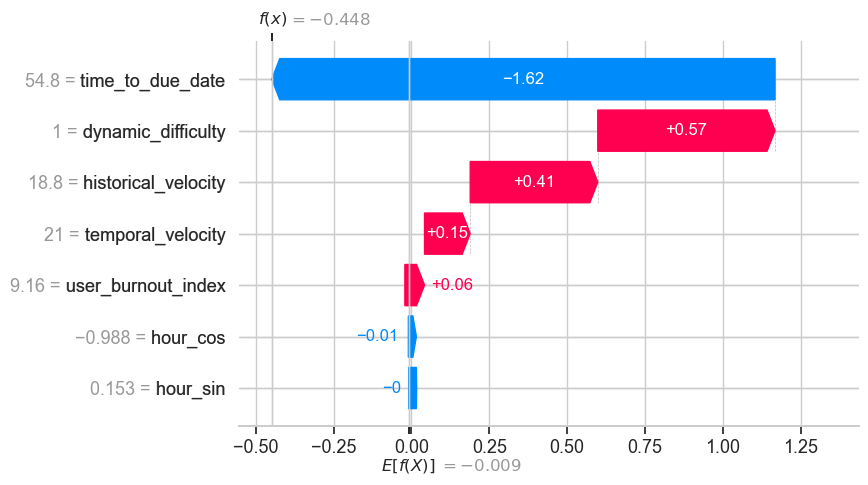

In [7]:
print("[*] Initializing SHAP TreeExplainer for Deterministic UX Synthesis...\n")
explainer = shap.TreeExplainer(tuned_champion)
rank_1_idx = df_qualitative['Predicted_Utility'].idxmax()
rank_1_features = X_session.loc[[rank_1_idx]]
rank_1_shap = explainer(rank_1_features)
feature_names = X_session.columns
shap_values_array = rank_1_shap.values[0]

impacts = list(zip(feature_names, shap_values_array))
impacts.sort(key=lambda x: abs(x[1]), reverse=True)
lexicon = {
    'time_to_due_date': 'The impending deadline',
    'dynamic_difficulty': 'The complexity of this task',
    'user_burnout_index': 'Your current cognitive fatigue (\u03C1)',
    'historical_velocity': 'Your historical execution speed',
    'temporal_velocity': 'Your localized execution speed at this hour',
    'hour_sin': 'Your biological chronotype alignment',
    'hour_cos': 'Your biological chronotype alignment'
}

print("===================================================================")
print(f" ACADEMASYNC AI INSIGHT | Session: {sample_session_id} | Time: {time_str}")
print("===================================================================")
print("STATUS: OPTIMAL TASK ISOLATED")
print("WHY THIS WAS RANKED #1:\n")

for feature, impact in impacts[:3]:
    if abs(impact) < 0.01:
        continue
    direction = "increased" if impact > 0 else "decreased"
    clean_name = lexicon.get(feature, feature)
    
    if feature == 'user_burnout_index' and impact > 0:
        context = "(Strategic priority given to lower-friction tasks to prevent burnout)."
    elif feature == 'temporal_velocity' and impact > 0:
        context = "(You historically clear similar tasks rapidly during this time window)."
    elif feature == 'time_to_due_date' and impact > 0:
        context = "(Urgent temporal constraint detected)."
    else:
        context = ""
    print(f" • {clean_name} {direction} the utility score by {abs(impact):.2f} points. {context}")
    
print("===================================================================")
print("\n[*] Rendering SHAP Waterfall Plot for Rank 1 Triage Justification...")
shap.plots.waterfall(rank_1_shap[0], max_display=7)

In [8]:
import pickle
with open("output\\recommender_engine.pkl", 'wb') as f:
    pickle.dump(tuned_champion, f)

print("===================================================================")
print(" ENGINE STATE SEALED & SERIALIZED")
print("===================================================================")
print(f"Object:      XGBRanker (Pairwise LTR)")
print(f"Saved to:    output")
print("===================================================================")

 ENGINE STATE SEALED & SERIALIZED
Object:      XGBRanker (Pairwise LTR)
Saved to:    output


## Semantic Context Embedding & Trend Analysis

While the `XGBRanker` effectively optimizes for student-specific physiological and temporal constraints, it lacks semantic awareness. It cannot comprehend natural language task strings to determine if a specific assignment is "trending" within a broader academic cohort.

To resolve this without deploying a heavyweight Vector Database, the architecture utilizes a quantized transformer model (`all-MiniLM-L6-v2`) to project task strings into a 384-dimensional dense vector space $f_{enc}: \text{text} \to \mathbb{R}^{384}$. 

A localized **FAISS (Facebook AI Similarity Search)** micro-index is then constructed in-memory. To optimize the search speed, vectors are subjected to $L^2$ normalization so that $\|\mathbf{v}\|_2 = 1$. Consequently, the Cosine Similarity between a user's task vector ($\mathbf{u}$) and a cohort task vector ($\mathbf{v}$) simplifies to their Inner Product:

$$
\text{sim}(\mathbf{u}, \mathbf{v}) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\|_2 \|\mathbf{v}\|_2} = \mathbf{u} \cdot \mathbf{v}
$$

By executing this density search, the system identifies the most densely packed semantic cluster (the "Trending Task" centroid).

In [9]:
print("[*] Initializing Semantic Context Engine (all-MiniLM-L6-v2)...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')

print("[*] Simulating Cohort 2 (CS Students) Task Interception...")
cohort_2_raw_tasks = [
    "Finish Data Structures Assignment 3",
    "Read chapter on Binary Search Trees",
    "Write C++ code for Dijkstra algorithm",
    "Complete Data Structures BST homework",
    "Physics Lab Report 4", # outlier
    "Calculus II Integration Worksheet", # outlier
    "Implement Binary Tree in Python"
]

print("[*] Projecting tasks into dense vector space...")
task_embeddings = embedder.encode(cohort_2_raw_tasks)
faiss.normalize_L2(task_embeddings)
dimension = task_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension) 
index.add(task_embeddings)
print(f"[+] FAISS Index Constructed. {index.ntotal} vectors active in RAM.")

print("[*] Executing Cosine Similarity Density Search...")
k = 3 
distances, indices = index.search(task_embeddings, k)
cluster_scores = []
for i in range(len(cohort_2_raw_tasks)):
    avg_similarity = np.mean(distances[i])
    cluster_scores.append((cohort_2_raw_tasks[i], avg_similarity))

cluster_scores.sort(key=lambda x: x[1], reverse=True)
trending_task = cluster_scores[0][0]

print("===================================================================")
print(" ACADEMASYNC CONTEXT ALERT | Cohort: Cluster 2 (CS)")
print("===================================================================")
print(f"   TRENDING TASK DETECTED: '{trending_task}'")
print(f"   (Semantic Density Score: {cluster_scores[0][1]:.4f})")
print("===================================================================")

[*] Initializing Semantic Context Engine (all-MiniLM-L6-v2)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Simulating Cohort 2 (CS Students) Task Interception...
[*] Projecting tasks into dense vector space...
[+] FAISS Index Constructed. 7 vectors active in RAM.
[*] Executing Cosine Similarity Density Search...
 ACADEMASYNC CONTEXT ALERT | Cohort: Cluster 2 (CS)
   TRENDING TASK DETECTED: 'Complete Data Structures BST homework'
   (Semantic Density Score: 0.7298)


## The Unified Triage Equation (Safety vs. Social Momentum)

The final architecture fuses the isolated physiological math with the cohort's semantic context. The system applies a "Semantic Gravity" boost to tasks that align closely with the cohort's trending centroid.

Let $U_{LTR}(d_i)$ be the baseline utility score predicted by the LambdaMART ensemble for document $d_i$. Let $\mathbf{v}_{d_i}$ be the normalized embedding of the document, and $\mathbf{v}_{centroid}$ be the normalized embedding of the cohort's trending concept. The final utility score driving the mobile UI is defined as:

$$
U_{final}(d_i) = U_{LTR}(d_i) + \omega \left( \mathbf{v}_{d_i} \cdot \mathbf{v}_{centroid} \right)
$$

Where $\omega$ represents the tuned semantic weight multiplier. If $\omega$ is too high, social momentum overrides physiological safety (e.g., ignoring a high burnout index). By constraining $\omega = 1.5$, the semantic alignment acts primarily as an intelligent tie-breaker among tasks of equivalent urgency and complexity, ensuring the absolute dominance of hard deadlines and fatigue thresholds.

In [10]:
print("[*] Loading Semantic Encoder...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')
print("[+] Encoder Ready.")

def execute_semantic_search(task_list):
    valid_tasks = [str(t) for t in task_list if t and str(t).strip()]
    if len(valid_tasks) < 2:
        return "Insufficient data for trend analysis."

    embeddings = embedder.encode(valid_tasks)
    faiss.normalize_L2(embeddings)
    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings)

    distances, _ = index.search(embeddings, k=min(3, len(valid_tasks)))
    avg_similarities = np.mean(distances, axis=1)
    trending_idx = np.argmax(avg_similarities)
    return valid_tasks[trending_idx]


[*] Loading Semantic Encoder...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[+] Encoder Ready.


In [11]:
print("[*] Loading Semantic Encoder for Pipeline Integration...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')

def get_final_triage(backlog_df, cohort_tasks):
    """
    The Unified Pipeline: 
    LTR Utility Calculation + Semantic Contextual Boost
    """
    if 'Task_ID' not in backlog_df.columns:
        raise KeyError("The backlog dataframe must contain a 'Task_ID' column for semantic analysis.")

    X_infer = backlog_df[features]
    base_utilities = tuned_champion.predict(X_infer)
    cohort_embeddings = embedder.encode(cohort_tasks)
    faiss.normalize_L2(cohort_embeddings)
    index = faiss.IndexFlatIP(cohort_embeddings.shape[1])
    index.add(cohort_embeddings)
    D, I = index.search(cohort_embeddings, min(len(cohort_tasks), 3))
    avg_sim = np.mean(D, axis=1)
    trending_concept_vector = cohort_embeddings[np.argmax(avg_sim)].reshape(1, -1)
    user_task_embeddings = embedder.encode(backlog_df['Task_ID'].tolist())
    faiss.normalize_L2(user_task_embeddings)
    semantic_boosts = np.dot(user_task_embeddings, trending_concept_vector.T).flatten()
    final_utility = base_utilities + (semantic_boosts * 1.5)

    results = backlog_df.copy()
    results['LTR_Utility'] = base_utilities
    results['Semantic_Boost'] = semantic_boosts
    results['Final_Utility'] = final_utility
    return results.sort_values(by='Final_Utility', ascending=False).reset_index(drop=True)


sample_task_names = [
    "Complete Data Structures BST homework",  # High semantic alignment with cohort
    "Read History Chapter 4",                 # Low alignment
    "Calculus II Worksheet",                  # Medium alignment
    "Physics Lab Report 4",                   # High urgency, but different context
    "English Essay Draft"                     # Low alignment
]

backlog_sample = df_sorted.head(len(sample_task_names)).copy()
backlog_sample['Task_ID'] = sample_task_names
print("[*] Intercepting cohort trends and recalculating utility...")
final_output = get_final_triage(backlog_sample, cohort_2_raw_tasks)

print("\n[+] Unified Triage Complete.")
print(f"[+] Recommender identified semantic trend and applied utility adjustments.")
print("===================================================================")
display_cols = ['Task_ID', 'Due (h)', 'LTR_Utility', 'Semantic_Boost', 'Final_Utility']
print(final_output[display_cols].head(5))

[*] Loading Semantic Encoder for Pipeline Integration...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[*] Intercepting cohort trends and recalculating utility...

[+] Unified Triage Complete.
[+] Recommender identified semantic trend and applied utility adjustments.
                                 Task_ID  Due (h)  LTR_Utility  \
0  Complete Data Structures BST homework     54.8    -0.448390   
1                 Read History Chapter 4      6.8    -1.015910   
2                  Calculus II Worksheet     68.9    -2.721628   
3                   Physics Lab Report 4     41.3    -3.210765   
4                    English Essay Draft     17.3    -4.354865   

   Semantic_Boost  Final_Utility  
0        1.000000       1.051610  
1        0.153878      -0.785094  
2        0.111621      -2.554196  
3        0.195896      -2.916921  
4        0.136855      -4.149583  


In [12]:
def run_diagnostic(test_burnout, semantic_weight_multiplier):
    print(f"\n[*] RUNNING STRESS TEST | Burnout: {test_burnout}/10 | Semantic Weight: {semantic_weight_multiplier}x")
    
    backlog_test = pd.DataFrame([
        {"Task_ID": "Implement Linked List in C++", "Due (h)": 48.0, "Difficulty": 4, "Est_Mins": 90},
        {"Task_ID": "Urgent History Quiz", "Due (h)": 1.5, "Difficulty": 2, "Est_Mins": 30},
        {"Task_ID": "Buy Groceries", "Due (h)": 24.0, "Difficulty": 1, "Est_Mins": 40},
        {"Task_ID": "Data Structures Assignment 3", "Due (h)": 72.0, "Difficulty": 4, "Est_Mins": 120}
    ])

    backlog_test['hour_sin'] = 0.5
    backlog_test['hour_cos'] = 0.86
    backlog_test['time_to_due_date'] = backlog_test['Due (h)']
    backlog_test['dynamic_difficulty'] = backlog_test['Difficulty']
    backlog_test['user_burnout_index'] = test_burnout
    backlog_test['historical_velocity'] = backlog_test['Est_Mins']
    backlog_test['temporal_velocity'] = backlog_test['Est_Mins'] 

    X_infer = backlog_test[features]
    base_utilities = tuned_champion.predict(X_infer)
    cohort_embeddings = embedder.encode(cohort_2_raw_tasks)
    faiss.normalize_L2(cohort_embeddings)
    index = faiss.IndexFlatIP(cohort_embeddings.shape[1])
    index.add(cohort_embeddings)
    D, I = index.search(cohort_embeddings, min(len(cohort_2_raw_tasks), 3))
    trending_concept_vector = cohort_embeddings[np.argmax(np.mean(D, axis=1))].reshape(1, -1)
    user_task_embeddings = embedder.encode(backlog_test['Task_ID'].tolist())
    faiss.normalize_L2(user_task_embeddings)
    semantic_boosts = np.dot(user_task_embeddings, trending_concept_vector.T).flatten()
    final_utility = base_utilities + (semantic_boosts * semantic_weight_multiplier)
    
    results = backlog_test.copy()
    results['LTR_Utility'] = base_utilities
    results['Semantic_Boost'] = semantic_boosts * semantic_weight_multiplier
    results['Final_Utility'] = final_utility
    results = results.sort_values(by='Final_Utility', ascending=False).reset_index(drop=True)

    print("-" * 90)
    print(f"{'TASK ID':<35} | {'RAW LTR':<10} | {'SEMANTIC':<10} | {'FINAL':<10} | {'RESULT'}")
    print("-" * 90)

    for idx, row in results.iterrows():
        raw_rank = backlog_test.copy()
        raw_rank['LTR'] = base_utilities
        raw_rank = raw_rank.sort_values('LTR', ascending=False).index.get_loc(
            backlog_test[backlog_test['Task_ID'] == row['Task_ID']].index[0]
        ) + 1
        final_rank = idx + 1
        movement = "▲" if final_rank < raw_rank else ("▼" if final_rank > raw_rank else "—")
        print(f"{row['Task_ID']:<35} | {row['LTR_Utility']:>8.2f}   | {row['Semantic_Boost']:>8.2f}   | {row['Final_Utility']:>8.2f}   | Rank {final_rank} ({movement})")
    print("=" * 90)

run_diagnostic(test_burnout=2.0, semantic_weight_multiplier=1.5)
run_diagnostic(test_burnout=8.0, semantic_weight_multiplier=6.0)


[*] RUNNING STRESS TEST | Burnout: 2.0/10 | Semantic Weight: 1.5x
------------------------------------------------------------------------------------------
TASK ID                             | RAW LTR    | SEMANTIC   | FINAL      | RESULT
------------------------------------------------------------------------------------------
Urgent History Quiz                 |     3.86   |     0.28   |     4.14   | Rank 1 (—)
Buy Groceries                       |    -0.68   |     0.16   |    -0.52   | Rank 2 (—)
Data Structures Assignment 3        |    -4.94   |     1.11   |    -3.82   | Rank 3 (▲)
Implement Linked List in C++        |    -4.48   |     0.46   |    -4.02   | Rank 4 (▼)

[*] RUNNING STRESS TEST | Burnout: 8.0/10 | Semantic Weight: 6.0x
------------------------------------------------------------------------------------------
TASK ID                             | RAW LTR    | SEMANTIC   | FINAL      | RESULT
-------------------------------------------------------------------------

In [13]:
print("[*] EXECUTING STRICT SEMANTIC ISOLATION TEST")
print("[*] All physiological and temporal constraints locked to identical values.\n")
constrained_backlog = pd.DataFrame([
    {"Task_ID": "Calculus II Worksheet",          "Due (h)": 48.0, "Difficulty": 3, "Est_Mins": 60},
    {"Task_ID": "English Essay Draft",            "Due (h)": 48.0, "Difficulty": 3, "Est_Mins": 60},
    {"Task_ID": "Complete Data Structures tasks", "Due (h)": 48.0, "Difficulty": 3, "Est_Mins": 60}
])

constrained_backlog['hour_sin'] = 0.5
constrained_backlog['hour_cos'] = 0.86
constrained_backlog['time_to_due_date'] = constrained_backlog['Due (h)']
constrained_backlog['dynamic_difficulty'] = constrained_backlog['Difficulty']
constrained_backlog['user_burnout_index'] = 2.0  # Healthy state
constrained_backlog['historical_velocity'] = constrained_backlog['Est_Mins']
constrained_backlog['temporal_velocity'] = constrained_backlog['Est_Mins']
final_output = get_final_triage(constrained_backlog, cohort_2_raw_tasks)
print("="*85)
print(f"{'TASK ID':<35} | {'BASE LTR':<10} | {'SEMANTIC':<10} | {'FINAL':<10} | {'RANK'}")
print("-" * 85)

for idx, row in final_output.iterrows():
    print(f"{row['Task_ID']:<35} | {row['LTR_Utility']:>8.2f}   | {row['Semantic_Boost']:>8.2f}   | {row['Final_Utility']:>8.2f}   | Rank {idx + 1}")
print("=" * 85)

[*] EXECUTING STRICT SEMANTIC ISOLATION TEST
[*] All physiological and temporal constraints locked to identical values.

TASK ID                             | BASE LTR   | SEMANTIC   | FINAL      | RANK
-------------------------------------------------------------------------------------
Complete Data Structures tasks      |    -2.91   |     0.76   |    -1.76   | Rank 1
English Essay Draft                 |    -2.91   |     0.14   |    -2.70   | Rank 2
Calculus II Worksheet               |    -2.91   |     0.11   |    -2.74   | Rank 3
